<a href="https://colab.research.google.com/github/MeryaneF/Sionna_RT_UFSM/blob/main/ct1_teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Esta é a primeira simulação utilizando o Sionna RT. O objetivo principal é avaliar o comportamento de uma rede operando na menor frequência permitida pelo simulador, buscando identificar a similaridade com uma rede real. A seguir, será apresentado o código utilizado, detalhado passo a passo, seguindo a estrutura do tutorial do site do Sionna RT e adaptado para este cenário específico**.

---



**1. Configurações Iniciais**

Inicialmente, são realizadas as importações necessárias para a simulação. Isso inclui as bibliotecas e módulos do Sionna RT, seguidos dos pacotes pyproj e utm, essenciais para manipulação de coordenadas. Além disso, os arquivos de cena gerados no Blender, que definem o ambiente da simulação, são importados.

Após as importações, a cena passa por um processo de descompactação para otimização. Em seguida, a cena é carregada no ambiente de simulação e, posteriormente, uma inspeção dos objetos carregados é realizada para verificar sua correta inclusão e posicionamento.

In [2]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

In [3]:
!pip install pyproj
!pip install utm


In [4]:
from google.colab import files
uploaded = files.upload()

Saving ct1.zip to ct1.zip


In [5]:
import zipfile
import os

# Descompacta o arquivo zip mantendo a estrutura
with zipfile.ZipFile("ct1.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

# Verifica se o XML e a pasta meshes estão no lugar
print(os.listdir("/content/ct1"))
print(os.listdir("/content/ct1/meshes"))

['ct12.xml', 'meshes']
['Pavilh_o_de_Laborat_rios_do_Centro_de_Tecnologia-itu_concrete.ply', 'Centro_de_Tecnologia-itu_brick.ply', 'element_003-itu_brick.ply', 'Centro_de_Tecnologia-itu_concrete.ply', 'Anexo_A_do_Centro_de_Tecnologia-itu_concrete.ply', 'element_002-itu_concrete.ply', 'Pavilh_o_de_Laborat_rios_do_Centro_de_Tecnologia-itu_brick.ply', 'element_002-itu_brick.ply', 'Anexo_C_do_Centro_de_Tecnologia-itu_concrete.ply', 'Anexo_C_do_Centro_de_Tecnologia-itu_brick.ply', 'element_003-itu_concrete.ply', 'Anexo_B_do_Centro_de_Tecnologia-itu_brick.ply', 'Anexo_B_do_Centro_de_Tecnologia-itu_concrete.ply', 'Plane.ply', 'Anexo_A_do_Centro_de_Tecnologia-itu_brick.ply']


In [6]:
from sionna.rt import load_scene

scene = load_scene("/content/ct1/ct12.xml")

In [7]:
#  Inspecionar objetos da cena
print(" Objetos da cena:")
for name, obj in scene.objects.items():
    print(f"  - {name}: {obj}")

# Acessar e inspecionar um objeto específico, como o 'floor'
if "floor" in scene.objects:
    floor = scene.get("floor")

    print(" Propriedades do objeto 'floor':")
    print("   Posição (x, y, z) [m]:", floor.position)
    print("   Orientação (α, β, γ) [rad]:", floor.orientation)
    print("  Escala:", floor.scaling)
    print("   Velocidade (x, y, z) [m/s]:", floor.velocity)
    print("   Material de rádio:\n", floor.radio_material)


 Objetos da cena:
  - Plane: <sionna.rt.scene_object.SceneObject object at 0x7d9d54f4adb0>
  - no-name-1: <sionna.rt.scene_object.SceneObject object at 0x7d9d08151c10>
  - no-name-2: <sionna.rt.scene_object.SceneObject object at 0x7d9d08182e70>


**2. Configuração da Rede e Parâmetros de Simulação**

Esta seção detalha a definição das coordenadas geográficas e sua conversão para um sistema de coordenadas local, a criação dos objetos de transmissão (Gateway) e recepção no ambiente do Sionna RT, a configuração de suas antenas e outros parâmetros essenciais para a simulação.

**2.1. Definição e Conversão de Coordenadas**

O primeiro passo é definir as coordenadas geográficas (latitude e longitude) do transmissor (gateway) e dos receptores. Para que o Sionna RT possa trabalhar com essas posições de forma mais eficiente e em um sistema de coordenadas local, é utilizada a projeção UTM (Universal Transversa de Mercator). Uma função auxiliar (latlon_to_local_xy) é implementada para converter as coordenadas geográficas para um sistema cartesiano (X, Y) relativo a um ponto de origem (o transmissor, neste caso), mantendo a altura (Z) como um valor absoluto.

**2.2. Configuração de Antenas**
Para as simulações, são definidos tipos de antenas para o transmissor e os receptores. No exemplo, são utilizadas antenas isotrópicas planas (PlanarArray) com polarização vertical. Antenas isotrópicas irradiam e recebem sinal igualmente em todas as direções, o que é útil para simulações iniciais e para entender o comportamento base da rede.

**2.3. Criação e Adição de Transmissores e Receptores na Cena**
Nesta etapa, os objetos Transmitter e Receiver são instanciados e adicionados à cena do Sionna RT. Antes de adicionar os novos objetos, qualquer transmissor ou receptor existente com os mesmos nomes é removido para evitar conflitos em execuções repetidas do script. O transmissor é posicionado na origem local (0,0, z_gateway), e os receptores são posicionados com base nas coordenadas convertidas e calculadas anteriormente. O look_at dos receptores é configurado para apontar para o transmissor, o que pode ser útil para certas análises de lóbulo de antena, embora para antenas isotrópicas isso não tenha impacto na irradiação.

In [8]:
from pyproj import Proj
from sionna.rt import PlanarArray, Transmitter, Receiver
import numpy as np

# Projeção UTM - Zona 22 Sul
proj_utm = Proj(proj='utm', zone=22, south=True, ellps='WGS84')

# Função para coordenadas relativas ao ponto de origem (lat0, lon0)
def latlon_to_local_xy(lat, lon, lat0, lon0):
    x0, y0 = proj_utm(lon0, lat0)
    x, y = proj_utm(lon, lat)
    dx = x - x0
    dy = y - y0
    return np.array([dx, dy])

# Coordenadas reais do gateway (Tx)
lat0 = -29.7132697
lon0 = -53.7177908
z_gateway = 9  # altura do transmissor

# Coordenadas dos receptores
receivers_geo = [
    ["CT - Pavilhão da mecânica", -29.71343, -53.71785],
    ["Centro de Tecnologia",      -29.71337, -53.71680]
]
z_rx = 5  # altura dos receptores

# Convertendo posições para sistema local automaticamente
rx_positions = []
for name, lat, lon in receivers_geo:
    xy = latlon_to_local_xy(lat, lon, lat0, lon0)
    pos = np.append(xy, z_rx)
    rx_positions.append(pos)


# Antenas
tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

# Remover Tx antigo
if "Tx1" in scene.transmitters:
    scene.remove("Tx1")

# Remover Rx antigos
for r in list(scene.receivers.values()):
    scene.remove(r.name)

# Transmissor
tx = Transmitter(
    name="Tx1",
    position=np.array([0.0, 0.0, z_gateway]),
    power_dbm=14.0,
    color=(1, 0, 0)
)
tx.array = tx_array
scene.add(tx)

# Receptores
for i, pos in enumerate(rx_positions):
    rx = Receiver(
        name=f"Rx{i+1}",
        position=pos,
        look_at=tx,
        color=(0, 1, 1)
    )
    rx.array = rx_array
    scene.add(rx)

# Mostrar posições finais
for i, pos in enumerate(rx_positions):
    print(f"Rx{i+1}: x={pos[0]:.2f} m, y={pos[1]:.2f} m, z={pos[2]:.2f} m")
#frequncia escolhida
scene.frequency= 1.01e9


Rx1: x=-5.31 m, y=-17.91 m, z=5.00 m
Rx2: x=96.15 m, y=-8.86 m, z=5.00 m


**3. Configuração da Camera**

 Após as configurações de TX e RX a cena é renderizada.

Transmitters no scene: dict_keys(['Tx1'])
Receivers no scene: dict_keys(['Rx1', 'Rx2'])


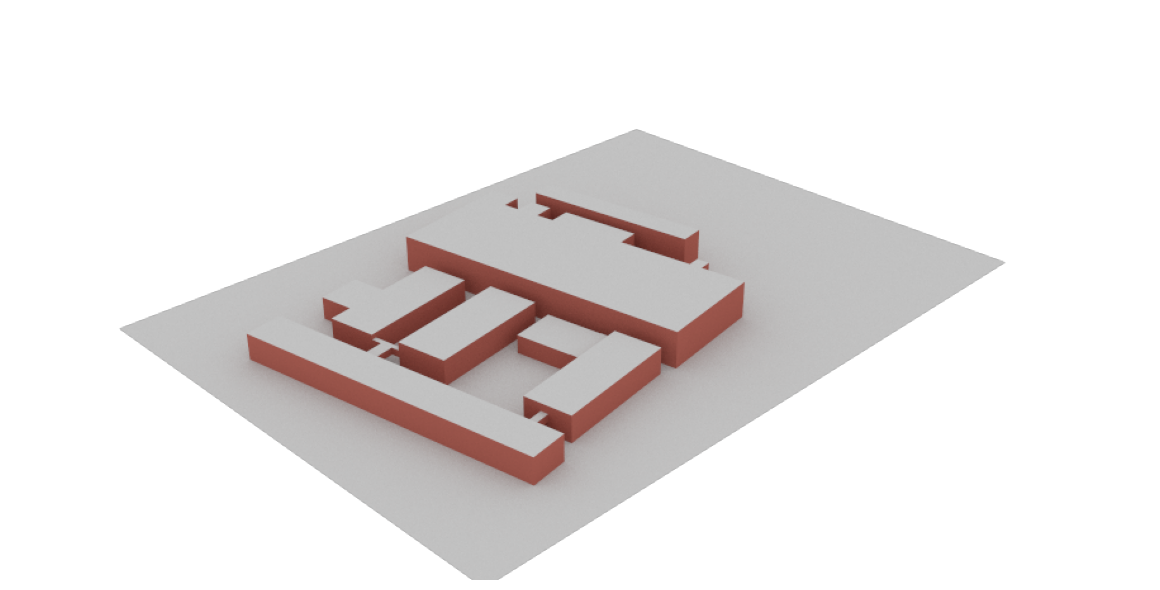

In [9]:
from sionna.rt import Camera

cam = Camera(position=[325, 325, 250], look_at=[1, 0, 0])
scene.render(camera=cam, resolution=[900, 450], num_samples=512, show_devices=True)
print("Transmitters no scene:", scene.transmitters.keys())
print("Receivers no scene:", scene.receivers.keys())


### 4. Cálculo de Caminhos de Propagação

Esta seção descreve a configuração das antenas do transmissor e do receptor, a inicialização do resolvedor de caminhos (`PathSolver`), o cálculo das trajetórias de propagação do sinal no ambiente simulado e a análise dos resultados obtidos, incluindo atrasos, potências e tipos de interação.

#### 4.1. Definição dos Arranjos de Antenas

São definidas as antenas tanto para o transmissor (Tx) quanto para o receptor (Rx) utilizando o objeto `PlanarArray`.

* O arranjo adotado é de **1x1 elementos** (uma antena simples).
* O padrão de radiação utilizado é **isotrópico** (`pattern="iso"`), o que significa que a antena irradia igualmente em todas as direções.
* A polarização é configurada como **vertical** (`polarization="V"`).
* Embora os parâmetros de espaçamento vertical e horizontal sejam definidos (`0.5 m`), eles não impactam o resultado neste caso, já que o arranjo possui apenas um elemento.

Essa configuração fornece uma base simples e neutra para as análises de propagação, sem privilegiar direções específicas.

#### 4.2. Inicialização do Solver e da Câmera

* O objeto `PathSolver` é instanciado para realizar o cálculo dos caminhos de propagação entre os dispositivos definidos na cena (`scene`).
* Um objeto `Camera` é configurado, posicionando o ponto de observação em coordenadas 3D e direcionando o campo de visão para o centro da cena.
* Esta câmera é utilizada posteriormente na etapa de renderização para a visualização gráfica dos caminhos encontrados.

#### 4.3. Cálculo dos Caminhos de Propagação

O cálculo dos caminhos é realizado pelo `PathSolver`, que percorre a cena em busca de trajetórias possíveis entre transmissor e receptor, considerando diversos fenômenos de propagação. Os parâmetros principais definidos são:

* `max_depth=5`: profundidade máxima de interações (até 5 reflexões/refrações sucessivas).
* `los=False`: a linha de visada direta (LoS – Line of Sight) não é considerada.
* `specular_reflection=True`: ativa reflexões especulares (como em superfícies lisas).
* `diffuse_reflection=True`: ativa reflexões difusas (espalhadas em várias direções).
* `refraction=True`: ativa refrações (mudança de meio).
* `synthetic_array=False`: mantém a simulação baseada no arranjo físico definido, sem antenas virtuais.
* `seed=42`: define a semente do gerador aleatório, garantindo reprodutibilidade.

#### 4.4. Extração e Processamento dos Caminhos

Após o cálculo, as seguintes informações são extraídas:

* **Atraso (τ)**: tempo de propagação de cada caminho, inicialmente em segundos e convertido para nanossegundos.
* **Amplitude (a)**: valor complexo associado à atenuação e fase do sinal em cada caminho.
* **Potência (P)**: calculada em decibéis (dB) a partir do módulo da amplitude.
* **Tipo de interação**: código numérico que identifica o tipo de fenômeno associado (ex.: reflexão, refração, difusão).

Esses dados são processados em arrays NumPy para facilitar a análise e manipulação.

#### 4.5. Apresentação dos Resultados

Os primeiros subcaminhos encontrados (até cinco, quando disponíveis) são listados em detalhes, incluindo:

* **Delay em nanossegundos**.
* **Potência recebida em dB**.
* **Tipo de interação** associado.

Esse resumo inicial fornece uma visão do comportamento da propagação no cenário.

#### 3.6. Renderização da Cena

A cena é renderizada em 3D para visualização:

* A resolução da imagem é definida em **800x600 pixels**.
* O parâmetro `num_samples=512` controla a qualidade da renderização, garantindo suavidade e realismo.
* Os transmissores e receptores são exibidos, juntamente com os caminhos de propagação calculados, permitindo inspeção visual dos resultados.

#### 3.7. Tratamento de Erros

Um bloco `try/except` garante que possíveis falhas durante o cálculo (como ausência de Tx/Rx ou erros na definição da cena) sejam capturadas e relatadas ao usuário, evitando a interrupção abrupta da execução.



Iniciando cálculo de caminhos...
 Caminhos encontrados: 2

Total de sub-caminhos: 422

Sub-caminho 1:
  - Delay: 395.55 ns
  - Potência: -105.11 dB
  - Tipo interação: 1

Sub-caminho 2:
  - Delay: 778.21 ns
  - Potência: -97.04 dB
  - Tipo interação: 1

Sub-caminho 3:
  - Delay: 246.11 ns
  - Potência: -107.69 dB
  - Tipo interação: 4

Sub-caminho 4:
  - Delay: 1277.78 ns
  - Potência: -109.47 dB
  - Tipo interação: 1

Sub-caminho 5:
  - Delay: 365.04 ns
  - Potência: -95.76 dB
  - Tipo interação: 1



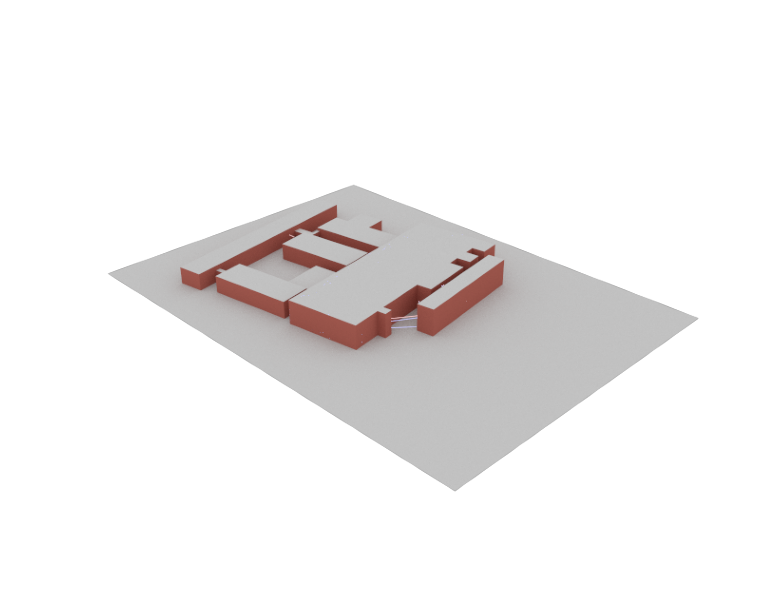

In [10]:
from sionna.rt import PathSolver, PlanarArray, Camera
import numpy as np

scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

p_solver = PathSolver()
cam = Camera(position=[-325, 325, 250], look_at=[0, 0, 0])

try:
    print("\nIniciando cálculo de caminhos...")

    paths = p_solver(scene=scene,
                     max_depth=5,
                     los=True,
                     specular_reflection=True,
                     diffuse_reflection=True,
                     refraction=True,
                     synthetic_array=False,
                     seed=42)

    num_paths = paths._tau.shape[0]
    print(f" Caminhos encontrados: {num_paths}")

    if num_paths > 0:
        np_tau = paths._tau.numpy().reshape(-1)
        np_a = np.concatenate([a.numpy().reshape(-1) for a in paths.a])
        np_interactions = paths.interactions.numpy().reshape(-1)

        print(f"\nTotal de sub-caminhos: {len(np_tau)}\n")

        for i in range(min(5, len(np_tau))):
            delay_ns = np_tau[i] * 1e9
            amp = np_a[i]
            power_db = 10 * np.log10(np.abs(amp)**2 + 1e-30)
            interaction = int(np_interactions[i])

            print(f"Sub-caminho {i+1}:")
            print(f"  - Delay: {delay_ns:.2f} ns")
            print(f"  - Potência: {power_db:.2f} dB")
            print(f"  - Tipo interação: {interaction}\n")

        scene.render(camera=cam, paths=paths, resolution=(800, 600), num_samples=512, show_devices=True)

    else:
        print(" Nenhum caminho encontrado entre Tx e Rx.")

except Exception as e:
    print(f"Erro durante o cálculo: {e}")


### 5. Análise e Visualização da Resposta ao Impulso do Canal (CIR)

Esta seção descreve a extração, processamento e visualização da **resposta ao impulso do canal** obtida a partir dos caminhos de propagação calculados pelo `PathSolver`. O objetivo é gerar gráficos que representem os atrasos e amplitudes dos subcaminhos, permitindo uma análise visual da dispersão temporal do sinal recebido.

#### 5.1. Extração de Dados do CIR

Os dados principais do CIR são obtidos a partir do objeto `paths`:

* `tau`: array contendo os **atrasos (delay)** de cada caminho em segundos.
* `a`: lista de arrays complexos representando as **amplitudes** dos caminhos.
* `a0`: seleciona o primeiro conjunto de amplitudes para processamento inicial.

O número de receptores (`num_rx`) é determinado pela dimensão do array de atrasos.


#### 5.2. Processamento de Atrasos e Amplitudes

Para cada receptor:

1. **Conversão de unidades:**

   * Os atrasos são convertidos de segundos para **nanossegundos**, facilitando a interpretação visual.

2. **Filtragem de valores válidos:**

   * Apenas atrasos positivos são considerados (`delays_ns > 0`), removendo valores inválidos ou não significativos.

3. **Organização para plotagem:**

   * Atrasos e amplitudes são ordenados de forma crescente pelos atrasos, garantindo que o gráfico represente corretamente a evolução temporal do sinal.

#### 5.3. Criação do Gráfico do CIR

Para cada receptor, é gerado um gráfico do tipo **stem plot**:

* `plt.stem` representa cada subcaminho como um marcador vertical, com a altura proporcional à amplitude do sinal.
* Marcadores e linhas têm tamanho e espessura ajustados para melhor visualização.
* Os cinco maiores picos de amplitude são destacados com **pontos vermelhos**, facilitando a identificação dos subcaminhos mais relevantes.

#### 5.4. Ajustes Visuais e Legendas

* Título do gráfico: `"Resposta do Impulso do Canal (CIR) - RxX"`, indicando o receptor correspondente.
* Eixos:

  * **X:** atraso em nanossegundos (`Delay (ns)`).
  * **Y:** amplitude do caminho (`Amplitude |a|`).
* Grade adicionada com linhas tracejadas e transparência (`alpha=0.5`) para facilitar a leitura.
* `plt.tight_layout()` ajusta automaticamente os elementos do gráfico para evitar sobreposição.
* `plt.show()` exibe o gráfico na tela.

#### 5.5. Objetivo e Interpretação

O gráfico resultante permite:

* Avaliar a **dispersão temporal** do canal.
* Identificar os **subcaminhos dominantes** (maiores amplitudes).
* Comparar visualmente o comportamento de diferentes receptores em termos de atraso e potência de cada caminho.


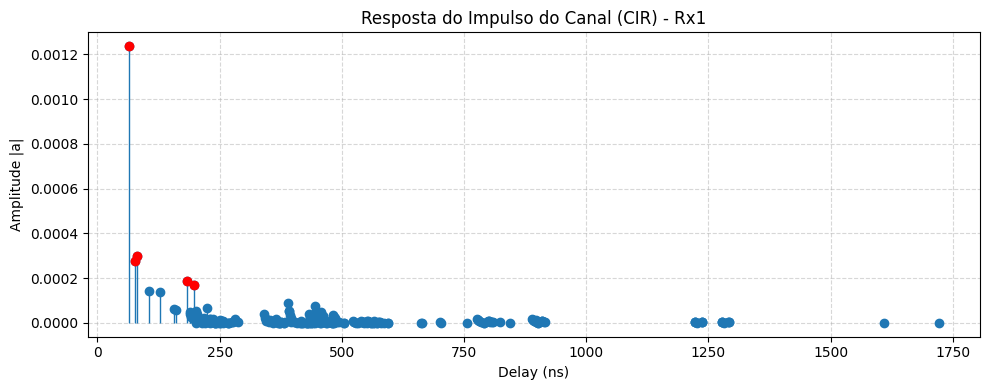

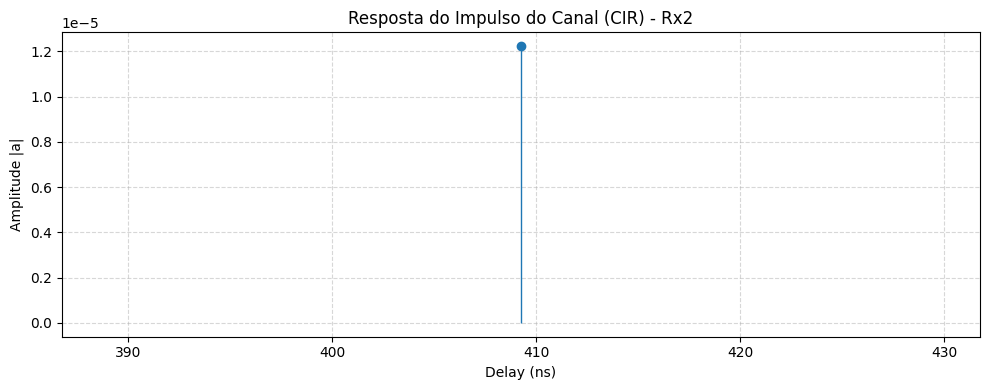

In [11]:
import matplotlib.pyplot as plt
import numpy as np

tau = paths._tau.numpy()
a = [x.numpy() for x in paths.a]
a0 = a[0]

num_rx = tau.shape[0]

for rx_idx in range(num_rx):
    delays_ns = tau[rx_idx, 0, 0, 0, :] / 1e-9
    amplitudes_abs = np.abs(a0)[rx_idx, 0, 0, 0, :]

    # Filtra somente valores válidos (delays positivos)
    valid = delays_ns > 0
    delays_ns_valid = delays_ns[valid]
    amplitudes_abs_valid = amplitudes_abs[valid]

    # Ordena atrasos e amplitudes para gráfico mais organizado
    sorted_indices = np.argsort(delays_ns_valid)
    delays_ns_sorted = delays_ns_valid[sorted_indices]
    amplitudes_abs_sorted = amplitudes_abs_valid[sorted_indices]

    plt.figure(figsize=(10, 4))
    markerline, stemlines, baseline = plt.stem(delays_ns_sorted, amplitudes_abs_sorted, basefmt=" ")

    # Ajusta tamanho do marcador e linha
    plt.setp(markerline, markersize=6)
    plt.setp(stemlines, linewidth=1)

    # Destaca os 5 maiores picos com pontos vermelhos
    if len(amplitudes_abs_sorted) >= 5:
        top_5_threshold = np.partition(amplitudes_abs_sorted, -5)[-5]
        for i, amp in enumerate(amplitudes_abs_sorted):
            if amp >= top_5_threshold:
                plt.plot(delays_ns_sorted[i], amp, 'ro')

    plt.title(f"Resposta do Impulso do Canal (CIR) - Rx{rx_idx+1}")
    plt.xlabel("Delay (ns)")
    plt.ylabel("Amplitude |a|")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [12]:
for rx_idx in range(num_rx):
    delays_ns = tau[rx_idx, 0, 0, 0, :] / 1e-9
    amplitudes_abs = np.abs(a0)[rx_idx, 0, 0, 0, :]
    print(f"Rx{rx_idx+1} delays (ns): {delays_ns}")
    print(f"Rx{rx_idx+1} amplitudes: {amplitudes_abs}")
    print()


Rx1 delays (ns): [ 395.54874   778.20593   246.11394  1277.7764    365.0377    392.34656
  800.32056  1236.662     594.88495   484.6906   1291.3706    909.9612
  576.99536   345.71625   447.24667   434.59122   476.31183   755.4798
  541.43585   556.2142    454.35596   524.3466    478.40958   460.52554
  554.2229    202.44052  1281.7316    240.68274   663.2465    396.12317
  343.79666  1226.6029    428.22153   544.1733     77.86151   383.42624
  436.13495   367.7707    375.84067   356.2389    896.23254   915.5069
  784.6833    806.62036   458.4244    900.9693    790.08905   188.61348
  565.2412    471.3885    229.41826   405.04224   495.02353   255.24066
  563.2818    446.08618   550.7052    219.10701   533.9126    503.5484
  408.7015    418.98648   381.28552   358.2171    467.61694   127.223305
  226.06529   480.33298   455.5278    415.41776   369.90836   250.51166
  244.16841   441.84793   241.10419   213.77177   157.15747   266.96213
  232.83276   286.83783   277.25223   249.75757   

### 6. Cálculo e Visualização da Resposta em Frequência do Canal (CFR)

Esta seção descreve a geração da **Channel Frequency Response (CFR)**, ou resposta em frequência do canal, a partir dos caminhos de propagação obtidos anteriormente. A CFR permite analisar como o canal LoRa se comporta em diferentes frequências dentro da faixa de operação, fornecendo informações sobre a atenuação e variação de fase do sinal ao longo do espectro.


#### 6.1. Definição da Faixa de Frequências

Para simular o comportamento do canal LoRa no Brasil, são definidos:

* `fc_start = 915e6 Hz`: frequência inicial da faixa LoRa.
* `fc_end = 928e6 Hz`: frequência final da faixa LoRa.
* `num_subchannels = 64`: número de subcanais fictícios, distribuídos uniformemente na faixa para análise detalhada.

```python
frequencies = np.linspace(fc_start, fc_end, num_subchannels)
```

Essa discretização permite observar como cada subcanal é afetado pelo ambiente de propagação.

#### 6.2. Cálculo da Resposta em Frequência

A CFR é calculada a partir do objeto `paths` utilizando o método `cfr`:

* `frequencies`: vetor de subcanais definidos anteriormente.
* `normalize=True`: normaliza a energia total do canal.
* `normalize_delays=True`: normaliza os atrasos de cada subcaminho, mantendo coerência temporal.
* `out_type="numpy"`: retorna os dados em formato NumPy para fácil manipulação e plotagem.

```python
h_freq = paths.cfr(
    frequencies=frequencies,
    normalize=True,
    normalize_delays=True,
    out_type="numpy"
)
```

O **shape esperado** do array resultante é:

```
[num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subchannels]
```

permitindo analisar a resposta para cada receptor, antena e instante de tempo.


#### 6.3. Visualização da CFR

Para análise visual, a amplitude da CFR é plotada para o primeiro receptor e antena:

* `plt.plot(frequencies/1e6, np.abs(h_freq)[0,0,0,0,0,:])` converte a frequência para **MHz** e plota a magnitude do canal.
* Título, legendas e grade são adicionados para clareza.
* A visualização permite identificar variações de ganho ou atenuação ao longo da faixa de LoRa.

```python
plt.figure(figsize=(8,4))
plt.plot(frequencies/1e6, np.abs(h_freq)[0,0,0,0,0,:])
plt.xlabel("Frequency (MHz)")
plt.ylabel(r"|$h_\text{freq}$|")
plt.title("Channel frequency response for LoRa 915–928 MHz")
plt.grid(True)
plt.show()
```



Shape of h_freq:  (2, 1, 1, 1, 1, 64)


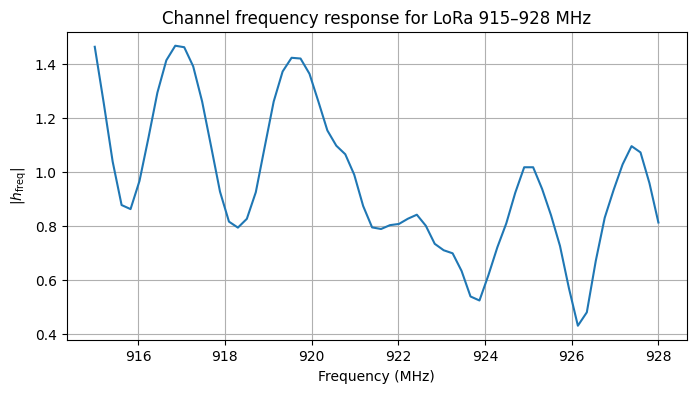

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sionna.rt import RadioMapSolver

fc_start = 915e6       # Início da faixa LoRa Brasil (Hz)
fc_end   = 928e6       # Fim da faixa LoRa Brasil (Hz)
num_subchannels = 64   # Número de subcanais fictícios para simulação

# Frequências dos subcanais
frequencies = np.linspace(fc_start, fc_end, num_subchannels)

# Configuração do canal / Sionna
h_freq = paths.cfr(
    frequencies=frequencies,
    normalize=True,         # Normaliza a energia
    normalize_delays=True,  # Normaliza os delays
    out_type="numpy"
)

print("Shape of h_freq: ", h_freq.shape)
# Shape esperado: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subchannels]


plt.figure(figsize=(8,4))
plt.plot(frequencies/1e6, np.abs(h_freq)[0,0,0,0,0,:])
plt.xlabel("Frequency (MHz)")
plt.ylabel(r"|$h_\text{freq}$|")
plt.title("Channel frequency response for LoRa 915–928 MHz")
plt.grid(True)
plt.show()



### 7. Geração e Visualização do Radio Map

Esta seção detalha a criação e renderização de um **Radio Map** (mapa de potência recebida) a partir da cena simulada no Sionna RT. O Radio Map fornece uma representação espacial da potência recebida ao longo da área de interesse, considerando reflexões, refrações e difusão do sinal.

#### 7.1. Inicialização do Radio Map Solver

* O objeto `RadioMapSolver` é instanciado para calcular a distribuição de potência do sinal no ambiente simulado.
* Este solver utiliza os mesmos fenômenos de propagação considerados no `PathSolver`, garantindo coerência entre o cálculo dos caminhos e o mapa resultante.

```python
rm_solver = RadioMapSolver()
```

#### 7.2. Cálculo do Radio Map

O Radio Map é gerado chamando o solver com os seguintes parâmetros:

* `scene`: cena 3D contendo transmissores, receptores e objetos que afetam a propagação.
* `max_depth=5`: profundidade máxima de interações, incluindo reflexões, refrações e difusões.
* `cell_size=[1,1]`: resolução espacial do mapa em metros; cada célula representa um ponto de amostragem da potência.
* `samples_per_tx=10**6`: número de raios lançados por transmissor para garantir precisão estatística nos cálculos.

```python
rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[1, 1],
               samples_per_tx=10**6)
```


#### 7.3. Renderização do Radio Map

Após o cálculo, o mapa de potência é renderizado na cena 3D para visualização:

* `camera=cam`: define o ponto de vista da renderização, usando a mesma câmera configurada anteriormente.
* `radio_map=rm`: sobrepõe o mapa de potência sobre a cena, permitindo visualização espacial da distribuição de sinal.
* `resolution=(800,400)`: define a resolução da imagem de saída.

```python
scene.render(camera=cam, radio_map=rm, resolution=(800, 400))
```

#### 7.4. Objetivo e Interpretação

O Radio Map gerado permite:

* Visualizar a **distribuição espacial da potência recebida** em toda a área simulada.
* Identificar regiões de **sinal forte e fraco**, auxiliando na análise de cobertura e planejamento de rede.
* Validar o comportamento do canal simulado, comparando-o com medições reais ou expectativas teóricas.

Essa etapa complementa a análise do CIR, fornecendo uma visão **global** da propagação do sinal na cena.



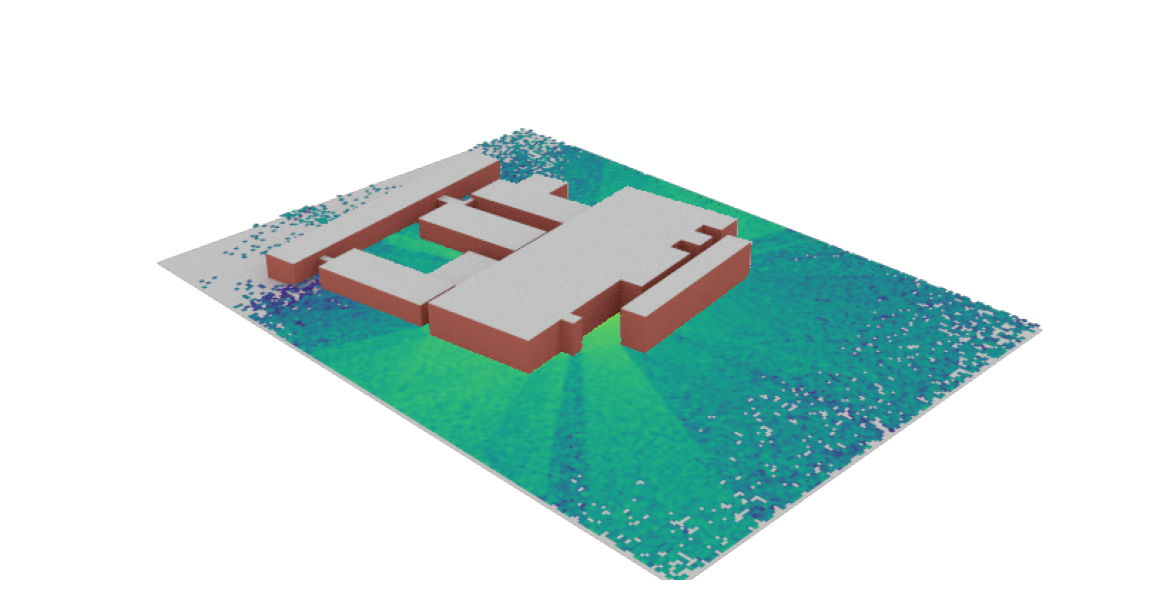

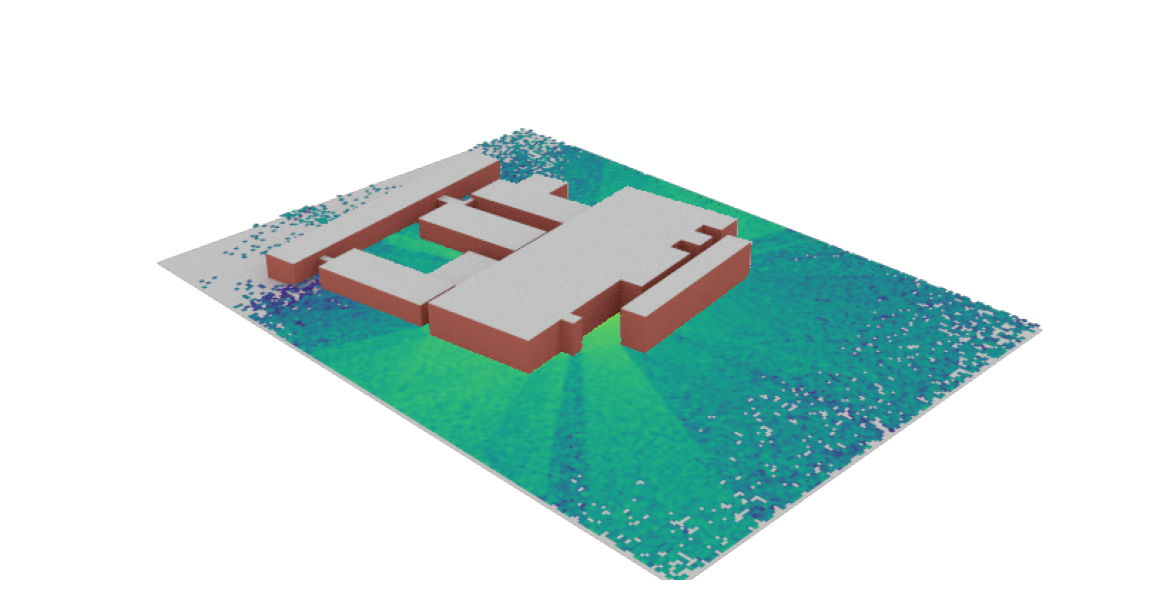

In [17]:
from sionna.rt import RadioMapSolver

rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[1, 1],
               samples_per_tx=10**6)

scene.render(camera=cam, radio_map=rm, resolution=(800, 400))